<a href="https://colab.research.google.com/github/engineerchacon/Redes-Neuronales-Profundas/blob/main/Ejercicio_de_aplicaci%C3%B3n_de_redes_GAN_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio de aplicación de redes GAN-Armando Chacón Terrazas**

# **Parte 1 – Reproducción del modelo base (MNIST)**

Ejecutar el código base proporcionado (GAN con MNIST).
Guardar y analizar:
Las imágenes generadas cada 10 épocas (función generate_images()).
La curva de pérdidas de generador y discriminador.
Incluir en el reporte:
Explicación de cómo se calcula y utiliza la pérdida en cada modelo.
Comentarios sobre el comportamiento observado:
→ ¿Qué tendencia muestran las pérdidas?
→ ¿Las imágenes mejoran con las épocas?

# **1: Preparar las herramientas y el espacio de trabajo**

In [1]:
# Importamos las herramientas principales de Google (TensorFlow) y de matemáticas
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. CREACIÓN DE LA CARPETA
output_dir = "resultados_gan"
os.makedirs(output_dir, exist_ok=True)

# 2. CONFIGURACIÓN DEL "CEREBRO" DE LA COMPUTADORA (GPU)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Todo listo: La computadora usará toda su potencia (GPU).")
    except RuntimeError as e:
        print("❌ Hubo un problema al configurar la potencia:", e)

✅ Todo listo: La computadora usará toda su potencia (GPU).


# **2: Cargar el material de estudio (Las imágenes reales)**

In [2]:
# Descargamos miles de imágenes de números escritos a mano (del 0 al 9).
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Preparación de las imágenes:
# Convertimos el color de los píxeles
# (que normalmente va de 0 a 255) a una escala de -1 a 1.
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

BUFFER_SIZE = 60000 # Cantidad total de imágenes
BATCH_SIZE = 128    # Para no saturar a la IA, le daremos las imágenes en "paquetes" de 128 en 128.

# Revolvemos las imágenes y las armamos en paquetes.
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print("Tenemos listas esta cantidad de imágenes para estudiar:", x_train.shape)

Tenemos listas esta cantidad de imágenes para estudiar: (60000, 28, 28, 1)


# **3: Crear a los "Jugadores" (El Falsificador y el Policía)**

In [3]:
# JUGADOR 1: EL GENERADOR (El Falsificador)
# Su trabajo es tomar "ruido" (manchas sin sentido) y transformarlo hasta
# dibujar un número que parezca real.
def build_generator():
    model = tf.keras.Sequential([
        # Comienza con 100 puntos de ruido aleatorio y los empieza a expandir
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),
        # Estas capas "Conv2DTranspose" son como pinceles que van agrandando
        # y detallando la imagen paso a paso.
        layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        # El último pincelazo: entrega una imagen final de 28x28 píxeles.
        layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

# JUGADOR 2: EL DISCRIMINADOR (El Policía)
# Su trabajo es mirar una imagen y decir: "¿Esto es un número real o un dibujo del falsificador?"
def build_discriminator():
    model = tf.keras.Sequential([
        # Usa capas "Conv2D" que actúan como una lupa para buscar imperfecciones en la imagen.
        layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3), # Cierra los ojos a veces para no memorizar, sino aprender patrones reales.
        layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        # Veredicto final: Entrega un número. 1 significa "Es Real", 0 significa "Es Falso".
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Damos vida a ambos jugadores
generator = build_generator()
discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **4: Establecer las Reglas del Juego (Pérdidas y Optimizadores)**

In [4]:
# Herramienta para calificar qué tan equivocados están
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

# ¿Cuándo pierde el Generador (Falsificador)?
# Pierde si el Policía califica sus imágenes falsas con un "0" (lo descubrió).
# Su objetivo es que el policía le ponga un "1".
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# ¿Cuándo pierde el Discriminador (Policía)?
# Pierde si dice que una imagen real es falsa, O si dice que una imagen falsa es real.
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output) # Analiza su error con las reales
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output) # Analiza su error con las falsas
    return real_loss + fake_loss

# LOS ENTRENADORES
# "Adam" es el algoritmo que les dice cómo ajustar sus cerebros para mejorar en la siguiente ronda.
g_optimizer = tf.keras.optimizers.Adam(1e-4)
d_optimizer = tf.keras.optimizers.Adam(1e-4)

# **5: Preparar las Funciones de Entrenamiento y Guardado**

In [5]:
EPOCHS = 50 # Número de "Rondas" o épocas que van a jugar.
noise_dim = 100 # Cantidad de ruido inicial para el generador.
num_examples = 16 # Guardaremos 16 imágenes de muestra para ver cómo mejoran.

# Creamos una "semilla" de ruido constante. Usaremos siempre esta misma mancha
# inicial para ver cómo el generador la va mejorando con el paso del tiempo.
seed = tf.random.normal([num_examples, noise_dim])

g_losses = [] # Aquí anotaremos los errores del falsificador
d_losses = [] # Aquí anotaremos los errores del policía

# Un paso de entrenamiento (Un turno del juego)
@tf.function
def train_step(images):
    # 1. Le damos ruido al falsificador
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    # 2. Observamos qué hacen ambos jugadores
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated = generator(noise, training=True) # El falsificador crea imágenes
        real_output = discriminator(images, training=True) # El policía evalúa las reales
        fake_output = discriminator(generated, training=True) # El policía evalúa las falsas

        # 3. Calculamos quién ganó y quién perdió este turno
        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    # 4. Calculamos exactamente en qué se equivocaron (Gradientes)
    gradients_gen = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    # 5. Los entrenadores (optimizadores) corrigen sus cerebros para el próximo turno
    g_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    return g_loss, d_loss

# Función para tomarle una "foto" al progreso y guardarla
def generate_images(model, epoch, test_input):
    # Le pedimos al modelo que dibuje usando nuestra "semilla" de ruido
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4,4))

    # Imprimimos las 16 imágenes en una cuadrícula
    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        # Regresamos los colores a la normalidad para que la pantalla los entienda
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Época {epoch}")

    # Guardamos la imagen en nuestra carpeta
    plt.savefig(f'{output_dir}/imagen_epoca_{epoch:03d}.png')
    plt.show()

# **6: El Bucle Principal**

Mostrando ruido inicial antes de estudiar...


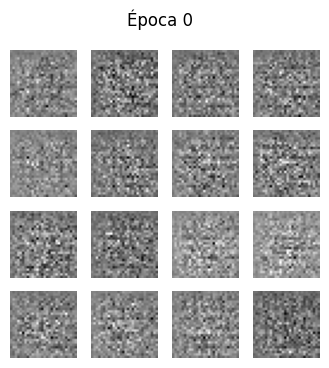

Ronda 1/50 | Error del Generador: 0.7483 | Error del Discriminador: 1.1924
Ronda 2/50 | Error del Generador: 0.8567 | Error del Discriminador: 1.2559
Ronda 3/50 | Error del Generador: 0.8374 | Error del Discriminador: 1.2768
Ronda 4/50 | Error del Generador: 0.9083 | Error del Discriminador: 1.2352
Ronda 5/50 | Error del Generador: 0.9012 | Error del Discriminador: 1.2216
Ronda 6/50 | Error del Generador: 0.9233 | Error del Discriminador: 1.2300
Ronda 7/50 | Error del Generador: 0.9921 | Error del Discriminador: 1.1880
Ronda 8/50 | Error del Generador: 1.0540 | Error del Discriminador: 1.1047
Ronda 9/50 | Error del Generador: 1.0512 | Error del Discriminador: 1.1505
Ronda 10/50 | Error del Generador: 1.1166 | Error del Discriminador: 1.0897


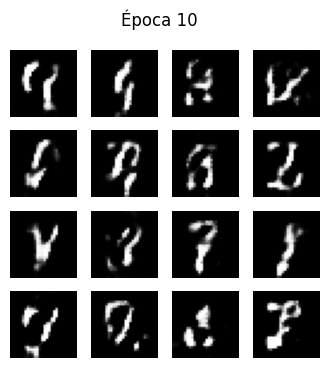

Ronda 11/50 | Error del Generador: 1.2104 | Error del Discriminador: 1.0385
Ronda 12/50 | Error del Generador: 1.2750 | Error del Discriminador: 1.0026
Ronda 13/50 | Error del Generador: 1.2917 | Error del Discriminador: 1.0034
Ronda 14/50 | Error del Generador: 1.1869 | Error del Discriminador: 1.1094
Ronda 15/50 | Error del Generador: 1.1287 | Error del Discriminador: 1.1383
Ronda 16/50 | Error del Generador: 1.0493 | Error del Discriminador: 1.1803
Ronda 17/50 | Error del Generador: 1.0087 | Error del Discriminador: 1.2015
Ronda 18/50 | Error del Generador: 1.0045 | Error del Discriminador: 1.1964
Ronda 19/50 | Error del Generador: 1.0277 | Error del Discriminador: 1.1894
Ronda 20/50 | Error del Generador: 0.9568 | Error del Discriminador: 1.2188


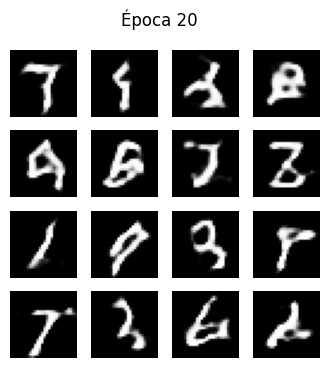

Ronda 21/50 | Error del Generador: 0.9485 | Error del Discriminador: 1.2386
Ronda 22/50 | Error del Generador: 1.0113 | Error del Discriminador: 1.2016
Ronda 23/50 | Error del Generador: 0.9396 | Error del Discriminador: 1.2364
Ronda 24/50 | Error del Generador: 0.9216 | Error del Discriminador: 1.2358
Ronda 25/50 | Error del Generador: 0.9614 | Error del Discriminador: 1.2276
Ronda 26/50 | Error del Generador: 0.9721 | Error del Discriminador: 1.2093
Ronda 27/50 | Error del Generador: 0.9058 | Error del Discriminador: 1.2446
Ronda 28/50 | Error del Generador: 0.9596 | Error del Discriminador: 1.2230
Ronda 29/50 | Error del Generador: 0.9311 | Error del Discriminador: 1.2342
Ronda 30/50 | Error del Generador: 0.9006 | Error del Discriminador: 1.2477


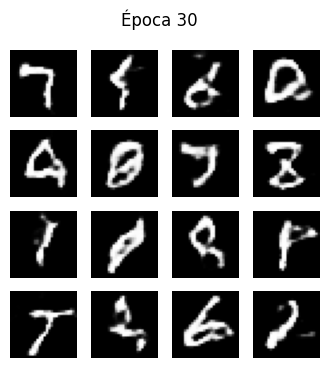

Ronda 31/50 | Error del Generador: 0.9619 | Error del Discriminador: 1.2199
Ronda 32/50 | Error del Generador: 0.9335 | Error del Discriminador: 1.2346
Ronda 33/50 | Error del Generador: 0.9053 | Error del Discriminador: 1.2458
Ronda 34/50 | Error del Generador: 0.9456 | Error del Discriminador: 1.2371
Ronda 35/50 | Error del Generador: 0.9538 | Error del Discriminador: 1.2272
Ronda 36/50 | Error del Generador: 0.9469 | Error del Discriminador: 1.2330
Ronda 37/50 | Error del Generador: 0.9336 | Error del Discriminador: 1.2326
Ronda 38/50 | Error del Generador: 0.9031 | Error del Discriminador: 1.2446
Ronda 39/50 | Error del Generador: 0.9321 | Error del Discriminador: 1.2389
Ronda 40/50 | Error del Generador: 0.9083 | Error del Discriminador: 1.2464


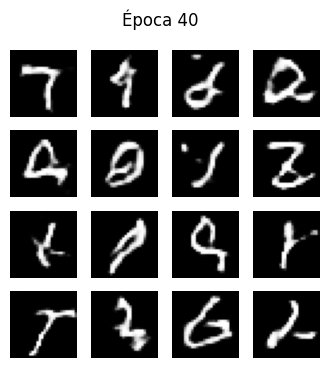

Ronda 41/50 | Error del Generador: 0.9440 | Error del Discriminador: 1.2414
Ronda 42/50 | Error del Generador: 0.9430 | Error del Discriminador: 1.2370
Ronda 43/50 | Error del Generador: 0.9201 | Error del Discriminador: 1.2446
Ronda 44/50 | Error del Generador: 0.9281 | Error del Discriminador: 1.2447
Ronda 45/50 | Error del Generador: 0.9140 | Error del Discriminador: 1.2455
Ronda 46/50 | Error del Generador: 0.9307 | Error del Discriminador: 1.2396
Ronda 47/50 | Error del Generador: 0.9374 | Error del Discriminador: 1.2434
Ronda 48/50 | Error del Generador: 0.9095 | Error del Discriminador: 1.2466
Ronda 49/50 | Error del Generador: 0.9148 | Error del Discriminador: 1.2571
Ronda 50/50 | Error del Generador: 0.9344 | Error del Discriminador: 1.2414


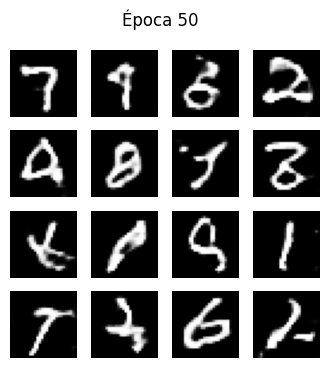

In [6]:
# LA RUTINA DE ENTRENAMIENTO COMPLETA
def train(dataset, epochs):
    # Mostramos cómo se ve la semilla antes de aprender nada (Puro ruido)
    print("Mostrando ruido inicial antes de estudiar...")
    generate_images(generator, 0, seed)

    # Repetimos el juego por 50 Rondas (Épocas)
    for epoch in range(epochs):
        g_loss_epoch = []
        d_loss_epoch = []

        # Para cada paquete de imágenes reales...
        for image_batch in dataset:
            # Juegan un turno
            g_loss, d_loss = train_step(image_batch)
            g_loss_epoch.append(g_loss)
            d_loss_epoch.append(d_loss)

        # Promediamos los errores de toda la ronda y los anotamos
        g_losses.append(np.mean(g_loss_epoch))
        d_losses.append(np.mean(d_loss_epoch))

        # Imprimimos en pantalla cómo van
        print(f"Ronda {epoch+1}/{epochs} | Error del Generador: {g_losses[-1]:.4f} | Error del Discriminador: {d_losses[-1]:.4f}")

        # Cada 10 rondas, tomamos una "foto" de su progreso para guardarla
        if (epoch + 1) % 10 == 0:
            generate_images(generator, epoch+1, seed)

# Iniciamos el entrenamiento
train(dataset, EPOCHS)

# **7: Análisis final (Generar la Gráfica)**

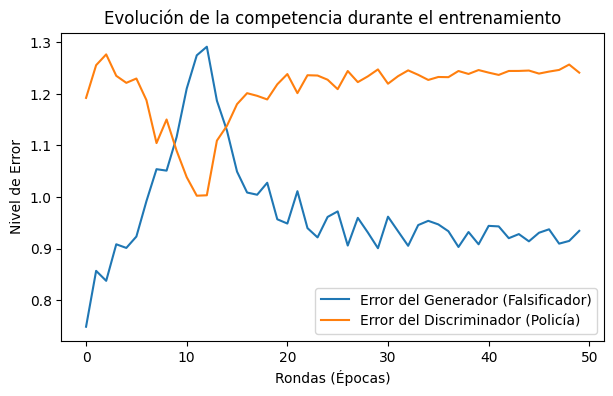

✅ ¡Entrenamiento completado! Revisa la carpeta lateral llamada 'resultados_gan' para descargar tus imágenes y gráfica.


In [7]:
# Mostrar y guardar curva de los errores al final
plt.figure(figsize=(7, 4))
plt.plot(g_losses, label="Error del Generador (Falsificador)")
plt.plot(d_losses, label="Error del Discriminador (Policía)")
plt.xlabel("Rondas (Épocas)")
plt.ylabel("Nivel de Error")
plt.title("Evolución de la competencia durante el entrenamiento")
plt.legend()

# Guardar la gráfica en la carpeta
plt.savefig(f'{output_dir}/curva_perdidas.png')
plt.show()

print(f"✅ ¡Entrenamiento completado! Revisa la carpeta lateral llamada '{output_dir}' para descargar tus imágenes y gráfica.")

# **Parte 2 – Experimento adicional-Base de datos Fashion-MNIST**

Usa la base tf.keras.datasets.fashion_mnist (con prendas de ropa). Esta base de datos tiene imágenes de las mismas dimensiones de la base de datos MNIST de números.

Reentrenar la misma arquitectura.
Observar si el modelo logra generar imágenes reconocibles (zapatillas, camisetas, etc.).
Comentar si el discriminador aprende más lentamente o rápidamente respecto a MNIST.

# **8: Preparar el nuevo vestuario (Fashion MNIST)**

In [8]:
# 1. CREAMOS UNA NUEVA CARPETA PARA LA ROPA
output_dir_fashion = "resultados_gan_fashion"
os.makedirs(output_dir_fashion, exist_ok=True)

# 2. CARGAMOS EL NUEVO CONJUNTO DE DATOS (Fashion MNIST)
print("Descargando imágenes de ropa...")
(x_train_f, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# 3. PREPARAMOS LAS IMÁGENES IGUAL QUE ANTES
# Convertimos los colores a la escala de -1 a 1
x_train_f = (x_train_f - 127.5) / 127.5
x_train_f = np.expand_dims(x_train_f, axis=-1)

# Revolvemos y empaquetamos las imágenes de ropa
dataset_fashion = tf.data.Dataset.from_tensor_slices(x_train_f).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print("Forma de los datos de entrenamiento de ropa:", x_train_f.shape)

Descargando imágenes de ropa...
Forma de los datos de entrenamiento de ropa: (60000, 28, 28, 1)


# **9: Crear nuevos jugadores reiniciando todo**

In [9]:
# CREAMOS NUEVOS MODELOS (Para que no tengan memoria de los números MNIST)
generator_f = build_generator()
discriminator_f = build_discriminator()

# NUEVOS ENTRENADORES (Optimizadores)
g_optimizer_f = tf.keras.optimizers.Adam(1e-4)
d_optimizer_f = tf.keras.optimizers.Adam(1e-4)

# Listas para guardar la historia de esta nueva competencia
g_losses_f = []
d_losses_f = []

# Nueva semilla de ruido específica para este experimento
seed_f = tf.random.normal([num_examples, noise_dim])

# **10: Las nuevas reglas y el inicio del entrenamiento**

Mostrando ruido inicial antes del entrenamiento...


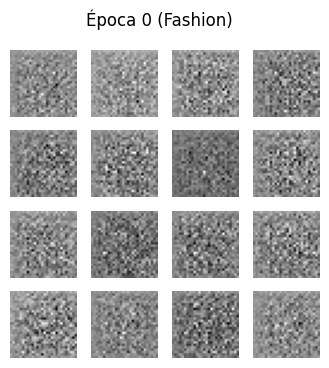

Ronda 1/50 | Error Gen: 0.8102 | Error Disc: 1.2099
Ronda 2/50 | Error Gen: 0.9104 | Error Disc: 1.2054
Ronda 3/50 | Error Gen: 0.9160 | Error Disc: 1.2594
Ronda 4/50 | Error Gen: 0.8867 | Error Disc: 1.2457
Ronda 5/50 | Error Gen: 0.8695 | Error Disc: 1.2267
Ronda 6/50 | Error Gen: 0.9170 | Error Disc: 1.2214
Ronda 7/50 | Error Gen: 0.9846 | Error Disc: 1.1506
Ronda 8/50 | Error Gen: 1.1010 | Error Disc: 1.0549
Ronda 9/50 | Error Gen: 1.2516 | Error Disc: 0.9934
Ronda 10/50 | Error Gen: 1.4017 | Error Disc: 0.8548


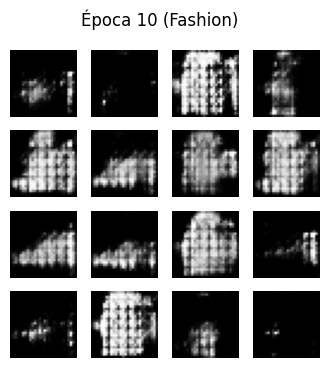

Ronda 11/50 | Error Gen: 1.6115 | Error Disc: 0.7475
Ronda 12/50 | Error Gen: 1.7054 | Error Disc: 0.7717
Ronda 13/50 | Error Gen: 1.6360 | Error Disc: 0.7724
Ronda 14/50 | Error Gen: 1.6186 | Error Disc: 0.8193
Ronda 15/50 | Error Gen: 1.7623 | Error Disc: 0.7534
Ronda 16/50 | Error Gen: 1.5883 | Error Disc: 0.8452
Ronda 17/50 | Error Gen: 1.5584 | Error Disc: 0.8355
Ronda 18/50 | Error Gen: 1.5139 | Error Disc: 0.8839
Ronda 19/50 | Error Gen: 1.5463 | Error Disc: 0.8677
Ronda 20/50 | Error Gen: 1.6199 | Error Disc: 0.8429


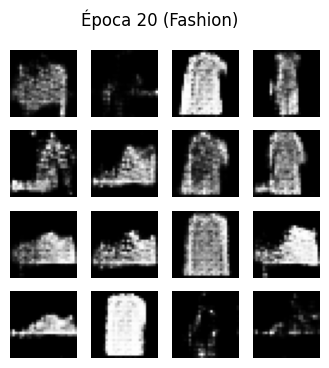

Ronda 21/50 | Error Gen: 1.5371 | Error Disc: 0.8836
Ronda 22/50 | Error Gen: 1.5273 | Error Disc: 0.8782
Ronda 23/50 | Error Gen: 1.6043 | Error Disc: 0.8480
Ronda 24/50 | Error Gen: 1.6202 | Error Disc: 0.8478
Ronda 25/50 | Error Gen: 1.4167 | Error Disc: 0.9782
Ronda 26/50 | Error Gen: 1.3329 | Error Disc: 1.0041
Ronda 27/50 | Error Gen: 1.3098 | Error Disc: 1.0111
Ronda 28/50 | Error Gen: 1.3841 | Error Disc: 0.9590
Ronda 29/50 | Error Gen: 1.3663 | Error Disc: 0.9752
Ronda 30/50 | Error Gen: 1.3963 | Error Disc: 0.9682


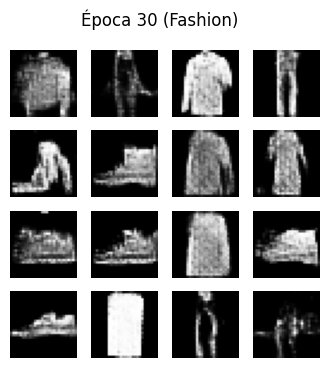

Ronda 31/50 | Error Gen: 1.2945 | Error Disc: 1.0335
Ronda 32/50 | Error Gen: 1.2911 | Error Disc: 1.0166
Ronda 33/50 | Error Gen: 1.3023 | Error Disc: 1.0149
Ronda 34/50 | Error Gen: 1.3306 | Error Disc: 0.9961
Ronda 35/50 | Error Gen: 1.2845 | Error Disc: 1.0184
Ronda 36/50 | Error Gen: 1.2924 | Error Disc: 1.0274
Ronda 37/50 | Error Gen: 1.3038 | Error Disc: 0.9958
Ronda 38/50 | Error Gen: 1.3016 | Error Disc: 1.0205
Ronda 39/50 | Error Gen: 1.2739 | Error Disc: 1.0333
Ronda 40/50 | Error Gen: 1.2597 | Error Disc: 1.0429


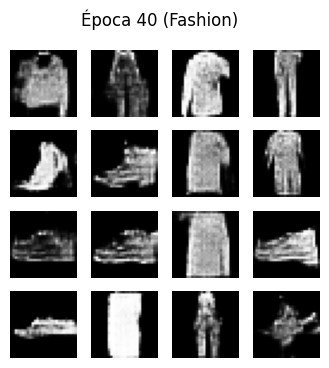

Ronda 41/50 | Error Gen: 1.2245 | Error Disc: 1.0607
Ronda 42/50 | Error Gen: 1.1755 | Error Disc: 1.0889
Ronda 43/50 | Error Gen: 1.1968 | Error Disc: 1.0631
Ronda 44/50 | Error Gen: 1.2105 | Error Disc: 1.0718
Ronda 45/50 | Error Gen: 1.1666 | Error Disc: 1.1001
Ronda 46/50 | Error Gen: 1.1446 | Error Disc: 1.1021
Ronda 47/50 | Error Gen: 1.1173 | Error Disc: 1.1290
Ronda 48/50 | Error Gen: 1.0930 | Error Disc: 1.1404
Ronda 49/50 | Error Gen: 1.1218 | Error Disc: 1.1070
Ronda 50/50 | Error Gen: 1.1340 | Error Disc: 1.1096


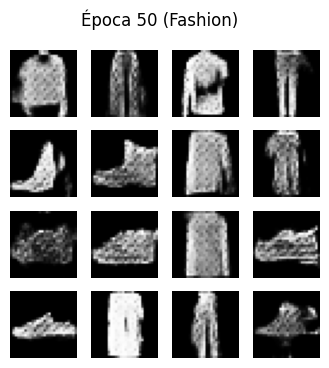

In [10]:
# Redefinimos el turno de entrenamiento para usar los modelos nuevos (generator_f y discriminator_f)
@tf.function
def train_step_fashion(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated = generator_f(noise, training=True)
        real_output = discriminator_f(images, training=True)
        fake_output = discriminator_f(generated, training=True)

        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(g_loss, generator_f.trainable_variables)
    gradients_disc = disc_tape.gradient(d_loss, discriminator_f.trainable_variables)

    g_optimizer_f.apply_gradients(zip(gradients_gen, generator_f.trainable_variables))
    d_optimizer_f.apply_gradients(zip(gradients_disc, discriminator_f.trainable_variables))

    return g_loss, d_loss

# Función modificada para guardar en la carpeta de ropa
def generate_images_fashion(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4,4))
    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Época {epoch} (Fashion)")
    plt.savefig(f'{output_dir_fashion}/imagen_epoca_{epoch:03d}.png')
    plt.show()

# ENTRENAMIENTO PRINCIPAL DE ROPA
def train_fashion(dataset, epochs):
    print("Mostrando ruido inicial antes del entrenamiento...")
    generate_images_fashion(generator_f, 0, seed_f)

    for epoch in range(epochs):
        g_loss_epoch = []
        d_loss_epoch = []

        for image_batch in dataset:
            g_loss, d_loss = train_step_fashion(image_batch)
            g_loss_epoch.append(g_loss)
            d_loss_epoch.append(d_loss)

        g_losses_f.append(np.mean(g_loss_epoch))
        d_losses_f.append(np.mean(d_loss_epoch))

        print(f"Ronda {epoch+1}/{epochs} | Error Gen: {g_losses_f[-1]:.4f} | Error Disc: {d_losses_f[-1]:.4f}")

        if (epoch + 1) % 10 == 0:
            generate_images_fashion(generator_f, epoch+1, seed_f)

# Iniciamos el entrenamiento con ropa
train_fashion(dataset_fashion, EPOCHS)

# **11: Resultados y Gráfica del experimento con Ropa**

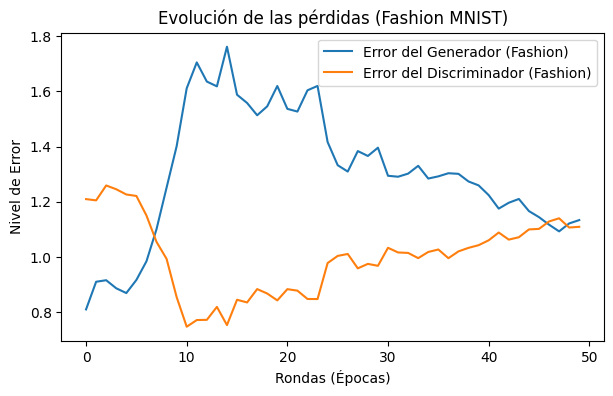

✅ Experimento Fashion MNIST completado. Revisa la carpeta 'resultados_gan_fashion'.


In [11]:
# Mostrar y guardar curva de pérdidas de Fashion MNIST
plt.figure(figsize=(7, 4))
plt.plot(g_losses_f, label="Error del Generador (Fashion)")
plt.plot(d_losses_f, label="Error del Discriminador (Fashion)")
plt.xlabel("Rondas (Épocas)")
plt.ylabel("Nivel de Error")
plt.title("Evolución de las pérdidas (Fashion MNIST)")
plt.legend()
plt.savefig(f'{output_dir_fashion}/curva_perdidas_fashion.png')
plt.show()

print(f"✅ Experimento Fashion MNIST completado. Revisa la carpeta '{output_dir_fashion}'.")